# Биграммы

In [1]:
import os
from string import punctuation
from nltk.tokenize import sent_tokenize
from pymorphy2 import MorphAnalyzer
import matplotlib.pyplot as plt
import numpy as np

morph = MorphAnalyzer()
punctuation+='«»' # Добавим кавычки, так как их в списке нет

Разбиваем тексты на предложения, переводим в нижний регистр, убираем пунктуацию и записываем в словарь

In [2]:
texts = {}
for file in os.listdir('./texts'):
    with open('./texts/' + file, encoding='utf8') as f:
        text = f.read()
        text = sent_tokenize(text)
        for i in range(len(text)):
            text[i] = ' '.join([word.lower().strip(punctuation).strip() for word in text[i].split()])
        texts[file[:-4]] = text

Лемматизация

In [3]:
for number, text in texts.items():
    for i in range(len(text)):
        lemmas = []
        for word in text[i].split(' '):
            ann = morph.parse(word)[0]
            lemmas.append(ann.normal_form)
        text[i] = ' '.join(lemmas)

## Со стоп-словами

In [215]:
bigramms_per_text = {}
bigramms_all = {}
for number, text in texts.items():
    bigramms_per_text[number] = dict()
    for sentence in text:
        for i in range(len(sentence.split(' ')) - 1):
            if sentence.split(' ')[i] != '':
                bigramm = sentence.split(' ')[i:i + 2]
                if len(bigramm) == 2:

                    if bigramms_per_text[number].get(' '.join(bigramm)):  # Если биграмма уже появлялась в этом тексте
                        bigramms_per_text[number][' '.join(bigramm)] += 1
                        bigramms_all[' '.join(bigramm)] += 1

                    elif bigramms_all.get(' '.join(bigramm)): #Если биграмма уже появялась в других текстах, но не в этом
                        bigramms_all[' '.join(bigramm)] += 1
                        bigramms_per_text[number][' '.join(bigramm)] = 1

                    else:   #Если это первый раз, когда эта биграмма встретилась за весь корпус
                        bigramms_all[' '.join(bigramm)] = 1

In [216]:
bigramms_all = {k: v for k, v in sorted(bigramms_all.items(), key=lambda item: item[1], reverse=True)}

## Визуализация

График с абсолютными числами

In [217]:
ind = list(bigramms_all.keys())[:20]
val = list(bigramms_all.values())[:20]

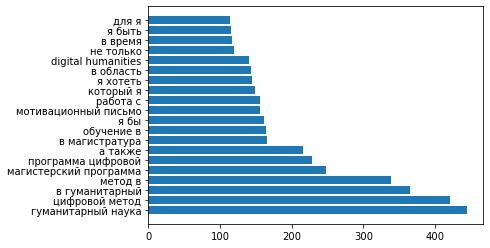

<Figure size 14400x14400 with 0 Axes>

In [218]:
plt.barh(ind, val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

График с процентами

In [219]:
total = 0
for element in val:
    total += element

In [220]:
percents = {}

for i in range(len(ind)):
    percents[ind[i]] = round(val[i] / total * 100)

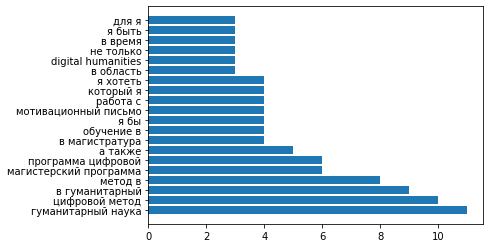

<Figure size 14400x14400 with 0 Axes>

In [221]:
plt.barh(ind, list(percents.values())[:20], align='center')
plt.figure(figsize=(200, 200))
plt.show()

## Без стоп-слов

In [4]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import copy

stops = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vlada\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
filtered_texts = copy.deepcopy(texts)

In [6]:
for number, text in filtered_texts.items():
    for i in range(len(text)):
        filtered = []
        for word in text[i].split(' '):
            if word not in stops:
                filtered.append(word)
        text[i] = ' '.join(filtered)

In [7]:
filt_bigramms_per_text = {}
filt_bigramms_all = {}
for number, text in filtered_texts.items():
    filt_bigramms_per_text[number] = dict()
    for sentence in text:
        for i in range(len(sentence.split(' ')) - 1):
            if sentence.split(' ')[i] != '':
                bigramm = sentence.split(' ')[i:i + 2]
                if len(bigramm) == 2:

                    if filt_bigramms_per_text[number].get(' '.join(bigramm)):  # Если биграмма уже появлялась в этом тексте
                        filt_bigramms_per_text[number][' '.join(bigramm)] += 1
                        filt_bigramms_all[' '.join(bigramm)] += 1

                    elif filt_bigramms_all.get(' '.join(bigramm)): #Если биграмма уже появялась в других текстах, но не в этом
                        filt_bigramms_all[' '.join(bigramm)] += 1
                        filt_bigramms_per_text[number][' '.join(bigramm)] = 1

                    else:   #Если это первый раз, когда эта биграмма встретилась за весь корпус
                        filt_bigramms_all[' '.join(bigramm)] = 1

In [8]:
filt_bigramms_all = {k: v for k, v in sorted(filt_bigramms_all.items(), key=lambda item: item[1], reverse=True)}

# Визуализация

График с абсолютными числами

In [227]:
filt_ind = list(filt_bigramms_all.keys())[:20]
filt_val = list(filt_bigramms_all.values())[:20]

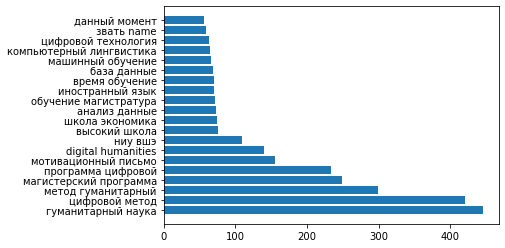

<Figure size 14400x14400 with 0 Axes>

In [228]:
plt.barh(filt_ind, filt_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

График с процентами

In [163]:
filt_total = 0
for element in filt_val:
    filt_total += element

In [167]:
filt_percents = {}

for i in range(len(filt_ind)):
    filt_percents[filt_ind[i]] = round(filt_val[i] / filt_total * 100)

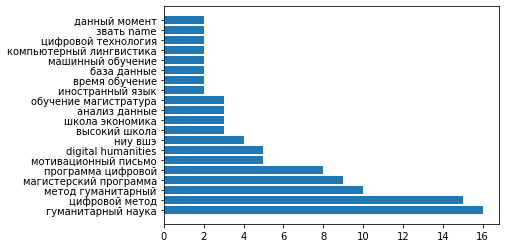

<Figure size 14400x14400 with 0 Axes>

In [168]:
plt.barh(filt_ind, list(filt_percents.values())[:20], align='center')
plt.figure(figsize=(200, 200))
plt.show()

## Выкидываем слова, нграммы с которыми нам неинтересны 

In [9]:
flit2_texts = copy.deepcopy(filtered_texts)

Слова, которые мы считаем лишними для нашего исследования

In [17]:
words = ['ниу', 'вшэ', 'цифровой', 'гуманитарный', 'магистерский', 'письмо', 'школа', 'магистратура', 'humanities', 'программа', 'метод', 'экономика', 'мотивационный', 'name', 'job', 'education', 'project']

In [18]:
for number, text in flit2_texts.items():
    for i in range(len(text)):
        filtered = []
        for word in text[i].split(' '):
            if word not in words:
                filtered.append(word)
        text[i] = ' '.join(filtered)

In [19]:
filt2_bigramms_per_text = {}
filt2_bigramms_all = {}
for number, text in flit2_texts.items():
    filt2_bigramms_per_text[number] = dict()
    for sentence in text:
        for i in range(len(sentence.split(' ')) - 1):
            if sentence.split(' ')[i] != '':
                bigramm = sentence.split(' ')[i:i + 2]
                if len(bigramm) == 2:

                    if filt2_bigramms_per_text[number].get(' '.join(bigramm)):  # Если биграмма уже появлялась в этом тексте
                        filt2_bigramms_per_text[number][' '.join(bigramm)] += 1
                        filt2_bigramms_all[' '.join(bigramm)] += 1

                    elif filt2_bigramms_all.get(' '.join(bigramm)): #Если биграмма уже появялась в других текстах, но не в этом
                        filt2_bigramms_all[' '.join(bigramm)] += 1
                        filt2_bigramms_per_text[number][' '.join(bigramm)] = 1

                    else:   #Если это первый раз, когда эта биграмма встретилась за весь корпус
                        filt2_bigramms_all[' '.join(bigramm)] = 1

In [20]:
filt2_bigramms_all = {k: v for k, v in sorted(filt2_bigramms_all.items(), key=lambda item: item[1], reverse=True)}

### Визуализация

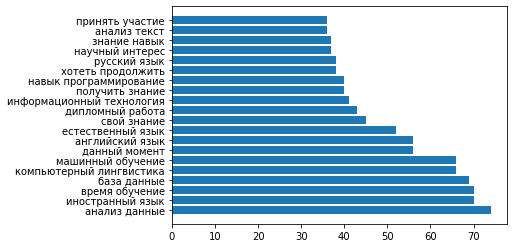

<Figure size 14400x14400 with 0 Axes>

In [21]:
filt2_ind = list(filt2_bigramms_all.keys())[:20]
filt2_val = list(filt2_bigramms_all.values())[:20]

plt.barh(filt2_ind, filt2_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

In [22]:
import csv
with open('top bigramms.csv', 'w', encoding='utf8') as file:
    w = csv.writer(file)
    for i in range(20):
        w.writerow((filt2_ind[i], filt2_val[i]))

Самые непопулярные

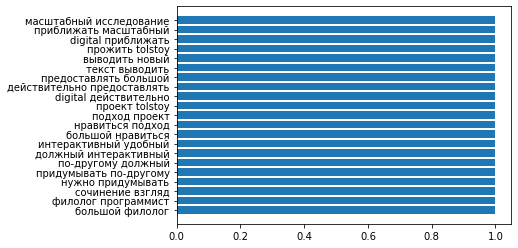

<Figure size 14400x14400 with 0 Axes>

In [235]:
filt2_ind = list(filt2_bigramms_all.keys())[-21:]
filt2_val = list(filt2_bigramms_all.values())[-21:]

plt.barh(filt2_ind, filt2_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

# Без лемматизации

In [236]:
nolemmas_texts = {}
for file in os.listdir('./texts'):
    with open('./texts/' + file, encoding='utf8') as f:
        text = f.read()
        text = sent_tokenize(text)
        for i in range(len(text)):
            text[i] = ' '.join([word.lower().strip(punctuation).strip() for word in text[i].split()])
        nolemmas_texts[file[:-4]] = text

In [237]:
for number, text in nolemmas_texts.items():
    for i in range(len(text)):
        filtered = []
        for word in text[i].split(' '):
            norm_form = morph.parse(word)[0].normal_form
            if norm_form not in words and norm_form not in stops:
                filtered.append(word)
        text[i] = ' '.join(filtered)

In [238]:
nolemmas_bigramms_per_text = {}
nolemmas_bigramms_all = {}
for number, text in nolemmas_texts.items():
    nolemmas_bigramms_per_text[number] = dict()
    for sentence in text:
        for i in range(len(sentence.split(' ')) - 1):
            if sentence.split(' ')[i] != '':
                bigramm = sentence.split(' ')[i:i + 2]
                if len(bigramm) == 2:

                    if nolemmas_bigramms_per_text[number].get(' '.join(bigramm)):  # Если биграмма уже появлялась в этом тексте
                        nolemmas_bigramms_per_text[number][' '.join(bigramm)] += 1
                        nolemmas_bigramms_all[' '.join(bigramm)] += 1

                    elif nolemmas_bigramms_all.get(' '.join(bigramm)): #Если биграмма уже появялась в других текстах, но не в этом
                        nolemmas_bigramms_all[' '.join(bigramm)] += 1
                        nolemmas_bigramms_per_text[number][' '.join(bigramm)] = 1

                    else:   #Если это первый раз, когда эта биграмма встретилась за весь корпус
                        nolemmas_bigramms_all[' '.join(bigramm)] = 1

In [239]:
nolemmas_bigramms_all = {k: v for k, v in sorted(nolemmas_bigramms_all.items(), key=lambda item: item[1], reverse=True)}

### Визуализация

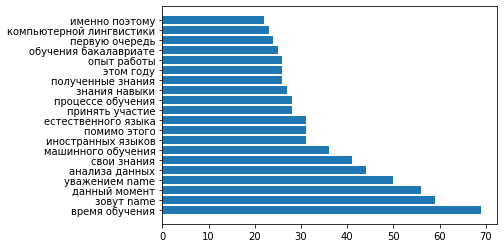

<Figure size 14400x14400 with 0 Axes>

In [240]:
nolemmas_ind = list(nolemmas_bigramms_all.keys())[:20]
nolemmas_val = list(nolemmas_bigramms_all.values())[:20]

plt.barh(nolemmas_ind, nolemmas_val, align='center')
plt.figure(figsize=(200, 200))
plt.show()

In [212]:
with open('ngramms.txt', 'w', encoding='utf8') as file:
    lst_k = [key for key in nolemmas_bigramms_all.keys()]
    lst_v = [val for val in nolemmas_bigramms_all.values()]
    for i in range(len(lst_k)):
        file.writelines(lst_k[i] + ' ' + str(lst_v[i]) +'\n')